# ML from DFT data

In [1]:
from sqlite3 import OptimizedUnicode
from unittest.mock import inplace
import matplotlib.pyplot as plt
import pandas as pd
from pygments.lexer import this
from scipy.io._test_fortran import __test_fortran_error
from Tools.DatasetTools.DatasetOperator import Dataset
from Tools.DatasetTools.Commoms import *
from matplotlib.patches import Patch
from Tools.DatasetTools.Tools import Plotting, PlottingChulls
from Tools.DatasetTools.MLConveniences import *
from matplotlib.path import Path

In [2]:
#plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

In [3]:
figwidth, figheight = plt.rcParams['figure.figsize']
plt.rc('text', usetex=True)

# Parameters 

In [4]:
target_name = 'EF_nmhcp'

In [5]:
DS = Dataset('Fe-Mo', target_name=target_name)

In [6]:
DS.BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.146330,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374554,0.363607,0.351444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111059,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.000000,0.000000,FM,C15,0.144169,0.144169,0.144169
Mo_sv1.bcc.NM,bulk bcc,15.828881 A,-10.932821,259.504388 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,1,0,1,0.000000,1.000000,NM,bcc,0.000000,0.000000,0.000000
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837515,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095306,0.095306,0.095306
Mo_sv1.fcc.NM,bulk fcc,16.059116 A,-10.511038,239.489255 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.012,0,1,...,1,0,1,0.000000,1.000000,NM,fcc,0.421784,0.421784,0.421784


# Targets

Text(0.5, 0, '$V_0$')

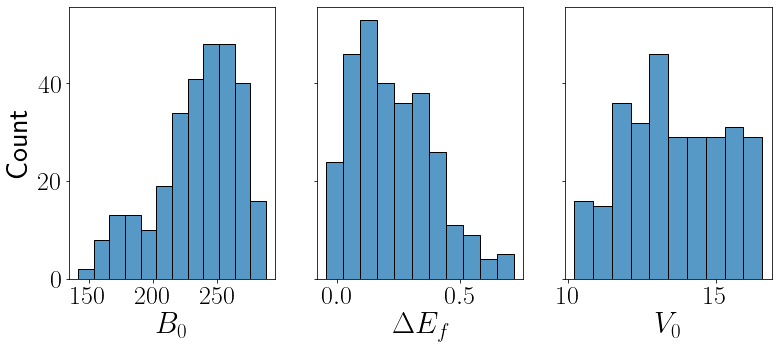

In [7]:
figwidth, figheight = plt.rcParams['figure.figsize']
fig, ax = plt.subplots(1,3, figsize=(3*figwidth*(3/5), figheight), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS[target_name], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel(r'$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel(r'$V_0$')

# Machine Learning 

In [8]:
resultslocation = DS.resultslocation

## Feature sets

In [9]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [10]:
Features['Canonical BOP']

,Structure,Mag,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,moments_1_CN12,...,Binf_0_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,U_bind,U_bond_atom,random
Fe_pv4Mo_sv20.C36-ABBBB.FM,3,1,-6.925199,-6.050627,0.0,0.000000,0.000000,-0.874571,0.689619,0.571110,...,0.390118,1.081732,1.156282,0.0,0.000000,0.000000,0.901327,-82.472282,-84.309469,0.226751
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,0,-7.069580,-2.079584,0.0,-0.750946,-0.317244,-3.921805,0.690493,0.433446,...,0.137907,1.192249,1.343511,0.0,1.139857,0.956735,0.947607,-186.101697,-189.259613,0.425458
Fe_pv2Mo_sv11.mu-BBABB.FM,9,1,-6.601047,-2.125589,0.0,-3.588088,-0.477620,-0.409750,0.647479,0.470223,...,0.166503,1.071112,1.222570,0.0,0.902495,0.748342,1.001885,-43.300202,-44.001731,0.878072
Fe_pv8Mo_sv22.sigma-BBBAB.NM,10,0,-6.958838,-1.238417,0.0,-5.296760,-0.423661,0.000000,0.658999,0.243336,...,0.000000,1.224173,1.311938,0.0,1.187306,1.155462,0.000000,-106.073592,-106.249550,0.390537
Fe_pv2Mo_sv11.mu-BBBBA.NM,9,0,-6.566157,-2.087629,0.0,-0.512510,-0.374860,-3.591159,0.647479,0.470223,...,0.166503,1.071112,1.222570,0.0,0.902495,0.748342,1.001885,-43.300202,-44.001731,0.143793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,2,1,-9.770953,-7.688316,0.0,0.000000,0.000000,-2.082637,1.635499,0.957173,...,0.618375,1.069390,1.032624,0.0,0.000000,0.000000,1.135754,-32.035307,-32.436815,0.406367
Mo_sv1.bcc.NM,5,0,-3.130925,0.000000,0.0,-3.130925,0.000000,0.000000,0.491648,0.000000,...,0.000000,1.261308,0.000000,0.0,1.261308,0.000000,0.000000,-3.130925,-3.130925,0.651701
Mo_sv8.A15.NM,0,0,-5.978096,-3.583571,0.0,-2.394525,0.000000,0.000000,0.531115,0.136149,...,0.000000,1.195488,1.177466,0.0,1.201725,0.000000,0.000000,-25.446069,-25.453952,0.878370
Mo_sv1.fcc.NM,7,0,-2.941773,-2.941773,0.0,0.000000,0.000000,0.000000,0.471662,0.471662,...,0.000000,1.140028,1.140028,0.0,0.000000,0.000000,0.000000,-2.941774,-2.941774,0.457024


In [11]:
for featurename in Features.keys():
    print(featurename)

atomic
dataset
SOAP_canonicalW_small
SOAP_specific_small
Pyscal
ACE
NOZERO-ACE
NOZERO_NOONE-ACE
NOZERO_NOONE_NOTWO-ACE
NOTHREE-ACE
NOTHREE-NOTWO-ACE
NOTHREE-NOTWO_NOONE-ACE
Canonical ACE
Canonical BOP
0.7dProjections 0.5OS BOP
0.7spProjections 0.5OS BOP
dataset + Canonical BOP
dataset + 0.7dProjections 0.5OS BOP
dataset + 0.7spProjections 0.5OS BOP
atomic no CNAV
dataset no CNAV
SOAP_canonicalW_small no CNAV
SOAP_specific_small no CNAV
Pyscal no CNAV
ACE no CNAV
NOZERO-ACE no CNAV
NOZERO_NOONE-ACE no CNAV
NOZERO_NOONE_NOTWO-ACE no CNAV
NOTHREE-ACE no CNAV
NOTHREE-NOTWO-ACE no CNAV
NOTHREE-NOTWO_NOONE-ACE no CNAV
Canonical ACE no CNAV
Canonical BOP no CNAV
0.7dProjections 0.5OS BOP no CNAV
0.7spProjections 0.5OS BOP no CNAV
dataset + Canonical BOP no CNAV
dataset + 0.7dProjections 0.5OS BOP no CNAV
dataset + 0.7spProjections 0.5OS BOP no CNAV


## test - train splits

In [12]:
samplesplit = DS.get_samplesplit()

# Optimized models

In [13]:
from Tools.DatasetTools.MLConveniences import filter_features
import joblib
dataset='Fe-Mo'

In [14]:
models = ['Kernel Ridge', 'Random Forest','MLP']

In [15]:
modelnames=[model.replace(' ','') for model in models]

In [16]:
voting_regressor_files = {modelname: os.path.join(dataset, 'results', f'voting_regressor_{modelname}.pkl')
                         for modelname in modelnames}

In [17]:
voting_regressor_files

{'KernelRidge': 'Fe-Mo/results/voting_regressor_KernelRidge.pkl',
 'RandomForest': 'Fe-Mo/results/voting_regressor_RandomForest.pkl',
 'MLP': 'Fe-Mo/results/voting_regressor_MLP.pkl'}

In [18]:
optimal_regressors = {}
for model in modelnames:
    optimal_regressors.update(joblib.load(voting_regressor_files[model]))

In [19]:
trainsamples = DS.samplesplit['train']; testsamples = DS.samplesplit['test']

In [20]:
ytrain = {}
ytest = {}
ypredict = {}
for (modelname, featurename), optimalregressor in optimal_regressors.items():
    #if modelname == 'Kernel Ridge' and 'BOP' in featurename:
    optimalregressor.fit(Features[featurename].loc[DS.samplesplit['train']], DS.target[DS.samplesplit['train']])
    ytrain[(modelname, featurename)] = pd.Series(optimalregressor.predict(Features[featurename].loc[DS.samplesplit['train']]),
                      index=DS.samplesplit['train']) 
    ytest[(modelname, featurename)] = pd.Series(optimalregressor.predict(Features[featurename].loc[DS.samplesplit['test']]),
                      index=DS.samplesplit['test']) 
    ypredict[(modelname, featurename)]= pd.concat([ytrain[(modelname, featurename)], ytest[(modelname, featurename)]], axis = 0)

In [21]:
P = Plotting()

In [22]:
CHULL_predict = {}
bs_phase = {}

In [23]:
phases = DS.StructureNames.unique()

In [24]:
for phase in phases:
    bs_phase[phase] = DS.BS[DS.StructureNames == phase].copy()
#for ( modelname, featurename ), this_ytrain in ytrain.items():
#    targetname = f'{target_name}__{featurename}__{modelname}'
#    bs_phase[phase][targetname] = ypredict[(modelname, featurename)][bs_phase[phase].index]
#    CHULL_predict[(modelname, featurename)] = P.get_convex_hulls(bs_phase, ['Fe', 'Mo'],getproperty=targetname)

In [25]:
ypredict[(modelname, featurename)][bs_phase[phase].index]

Fe_pv2Mo_sv6.A15-BA.FM    0.150595
Fe_pv6Mo_sv2.A15-AB.FM    0.111530
Fe_pv8.A15.NM             0.183922
Mo_sv8.A15.FM             0.181298
Fe_pv2Mo_sv6.A15-BA.NM    0.193824
Fe_pv6Mo_sv2.A15-AB.NM    0.158453
Mo_sv8.A15.NM             0.239139
dtype: float64

In [26]:
CHULL_dft = P.get_convex_hulls(bs_phase, ['Fe', 'Mo'],getproperty=target_name)

In [27]:
#for (modelname, featurename), chull_predict in CHULL_predict.items():
#    break

In [28]:
#for phase, this_chull_predict in chull_predict.items():
#    break
#    

In [29]:
#    all_vertices_low = np.unique(np.hstack(this_chull_predict.simplices[this_chull_predict.good]))

In [30]:
#fig, ax = plt.subplots()
#ax.plot(
#    bs_phase[phase].iloc[all_vertices_low]['Fe_pv'].values,
#    bs_phase[phase].iloc[all_vertices_low][target_name].values,
#)
#sns.scatterplot(bs_phase[phase][['Fe_pv', target_name]], x='Fe_pv', y=target_name, ax = ax)

In [31]:
bs_phase[phase]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv2Mo_sv6.A15-BA.FM,bulk A15-BA.FM,14.757480 A,-10.202329,238.003165 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,6,8,0.25,0.75,FM,A15,0.061044,0.061044,0.061044
Fe_pv6Mo_sv2.A15-AB.FM,bulk A15-AB.FM,12.624795 A,-8.867454,203.806345 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,6,2,8,0.75,0.25,FM,A15,0.057155,0.057155,0.057155
Fe_pv8.A15.NM,bulk A15,10.455748 A,-7.944386,272.134465 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,8,0,8,1.00,0.00,NM,A15,0.310842,0.239686,0.160626
Mo_sv8.A15.FM,bulk A15.FM,16.077050 A,-10.839029,253.594611 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,8,0,8,0.00,1.00,FM,A15,0.093726,0.093726,0.093726
Fe_pv2Mo_sv6.A15-BA.NM,bulk A15-BA,14.576462 A,-10.160270,258.169112 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.019,0,2,...,2,6,8,0.25,0.75,NM,A15,0.103153,0.085364,0.065599
Fe_pv6Mo_sv2.A15-AB.NM,bulk A15-AB,11.909537 A,-8.643537,260.948492 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.018,0,2,...,6,2,8,0.75,0.25,NM,A15,0.281089,0.227722,0.168426
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837515,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.00,1.00,NM,A15,0.095306,0.095306,0.095306


In [32]:
bs_phase = DS.BS[DS.StructureNames == phase]

# Optimized Scores 

In [33]:
scoresfiles = {model:f'{DS.dataset}/results/{DS.dataset}_{model}_OptimalScores_{target_name}.pkl'
              for model in models}

In [34]:
OptimizedScores = {
    model: pd.read_pickle(scoresfiles[model])
    for model in models if os.path.exists(scoresfiles[model]) 
}

In [35]:
OptimizedScores['Kernel Ridge'].sort_values(by='test')

test     train  orig_len
Kernel Ridge ACE                                 0.015711  0.007089      1803
             SOAP_specific_small                 0.018157  0.007219      1653
             ACE no CNAV                         0.018480  0.009414       303
             0.7dProjections 0.5OS BOP           0.021383  0.009072       417
             SOAP_specific_small no CNAV         0.022146  0.013968       278
             0.7spProjections 0.5OS BOP          0.025133  0.010237       429
             0.7spProjections 0.5OS BOP no CNAV  0.032853  0.020257        74
             0.7dProjections 0.5OS BOP no CNAV   0.037295  0.022984        72
             dataset no CNAV                     0.071394  0.078073        17
             dataset                             0.074732  0.057352        32
             Canonical BOP                       0.093085  0.083219       405
             Canonical BOP no CNAV               0.112912  0.089237        70
             SOAP_canonicalW_small no CNAV       0.129078  0.120286        78
             Canonical ACE                       0.129839  0.118894       417
             Canonical ACE no CNAV               0.130723  0.118860        72
             atomic no CNAV                      0.157099  0.146335       135
             atomic                              0.157243  0.146457       135
             SOAP_canonicalW_small               0.160003  0.132761       453

In [36]:
newtables = []
for model, table in OptimizedScores.items():
    newtable = table.droplevel(0)
    newtable.columns = pd.MultiIndex.from_tuples( [(model, case) for case in newtable.columns])
    newtables.append(newtable)

In [37]:
fulltable = pd.concat(newtables, axis = 1)

In [38]:
fulltable.sort_values(by=('Kernel Ridge', 'test'), inplace=True)

In [39]:
fulltable

Kernel Ridge                     \
                                           test     train orig_len   
ACE                                    0.015711  0.007089     1803   
SOAP_specific_small                    0.018157  0.007219     1653   
ACE no CNAV                            0.018480  0.009414      303   
0.7dProjections 0.5OS BOP              0.021383  0.009072      417   
SOAP_specific_small no CNAV            0.022146  0.013968      278   
0.7spProjections 0.5OS BOP             0.025133  0.010237      429   
0.7spProjections 0.5OS BOP no CNAV     0.032853  0.020257       74   
0.7dProjections 0.5OS BOP no CNAV      0.037295  0.022984       72   
dataset no CNAV                        0.071394  0.078073       17   
dataset                                0.074732  0.057352       32   
Canonical BOP                          0.093085  0.083219      405   
Canonical BOP no CNAV                  0.112912  0.089237       70   
SOAP_canonicalW_small no CNAV          0.129078  0.120286       78   
Canonical ACE                          0.129839  0.118894      417   
Canonical ACE no CNAV                  0.130723  0.118860       72   
atomic no CNAV                         0.157099  0.146335      135   
atomic                                 0.157243  0.146457      135   
SOAP_canonicalW_small                  0.160003  0.132761      453   

                                   Random Forest                 MLP            
                                            test     train      test     train  
ACE                                     0.029258  0.019998  0.028454  0.028508  
SOAP_specific_small                     0.032118  0.022033  0.031860  0.030856  
ACE no CNAV                             0.037705  0.020230  0.029147  0.028673  
0.7dProjections 0.5OS BOP               0.034670  0.019370  0.031157  0.030407  
SOAP_specific_small no CNAV             0.031733  0.018845  0.031750  0.033654  
0.7spProjections 0.5OS BOP              0.038859  0.024773  0.037158  0.034597  
0.7spProjections 0.5OS BOP no CNAV      0.053363  0.027194  0.039356  0.038883  
0.7dProjections 0.5OS BOP no CNAV       0.045526  0.022426  0.037791  0.041323  
dataset no CNAV                         0.121261  0.036870  0.108158  0.086881  
dataset                                 0.059716  0.025915  0.064068  0.054767  
Canonical BOP                           0.089620  0.040462  0.088513  0.088783  
Canonical BOP no CNAV                   0.136279  0.074492  0.108642  0.103214  
SOAP_canonicalW_small no CNAV           0.124339  0.101959  0.119765  0.122299  
Canonical ACE                           0.122584  0.103996  0.116312  0.120172  
Canonical ACE no CNAV                   0.140295  0.084831  0.128831  0.131654  
atomic no CNAV                          0.148976  0.104898  0.145279  0.145950  
atomic                                  0.150437  0.104001  0.146035  0.146225  
SOAP_canonicalW_small                   0.122498  0.099918  0.112171  0.110248

In [40]:
fulltable = fulltable[~fulltable.index.str.contains('spProjections')]

In [41]:
fulltable.index = fulltable.index.str.replace('SOAP_canonicalW_small', 'Canonical SOAP', regex=True)
fulltable.index = fulltable.index.str.replace('SOAP_specific_small', 'SOAP', regex=True)
fulltable.index = fulltable.index.str.replace('.*BOP', 'BOP', regex=True)

In [42]:
fulltable

Kernel Ridge                    Random Forest  \
                               test     train orig_len          test   
ACE                        0.015711  0.007089     1803      0.029258   
SOAP                       0.018157  0.007219     1653      0.032118   
ACE no CNAV                0.018480  0.009414      303      0.037705   
BOP                        0.021383  0.009072      417      0.034670   
SOAP no CNAV               0.022146  0.013968      278      0.031733   
BOP no CNAV                0.037295  0.022984       72      0.045526   
dataset no CNAV            0.071394  0.078073       17      0.121261   
dataset                    0.074732  0.057352       32      0.059716   
BOP                        0.093085  0.083219      405      0.089620   
BOP no CNAV                0.112912  0.089237       70      0.136279   
Canonical SOAP no CNAV     0.129078  0.120286       78      0.124339   
Canonical ACE              0.129839  0.118894      417      0.122584   
Canonical ACE no CNAV      0.130723  0.118860       72      0.140295   
atomic no CNAV             0.157099  0.146335      135      0.148976   
atomic                     0.157243  0.146457      135      0.150437   
Canonical SOAP             0.160003  0.132761      453      0.122498   

                                       MLP            
                           train      test     train  
ACE                     0.019998  0.028454  0.028508  
SOAP                    0.022033  0.031860  0.030856  
ACE no CNAV             0.020230  0.029147  0.028673  
BOP                     0.019370  0.031157  0.030407  
SOAP no CNAV            0.018845  0.031750  0.033654  
BOP no CNAV             0.022426  0.037791  0.041323  
dataset no CNAV         0.036870  0.108158  0.086881  
dataset                 0.025915  0.064068  0.054767  
BOP                     0.040462  0.088513  0.088783  
BOP no CNAV             0.074492  0.108642  0.103214  
Canonical SOAP no CNAV  0.101959  0.119765  0.122299  
Canonical ACE           0.103996  0.116312  0.120172  
Canonical ACE no CNAV   0.084831  0.128831  0.131654  
atomic no CNAV          0.104898  0.145279  0.145950  
atomic                  0.104001  0.146035  0.146225  
Canonical SOAP          0.099918  0.112171  0.110248

In [43]:
with open('full_table.tex', 'w') as f:
    f.write(fulltable.to_latex(
        index=True,
        escape=False,
        sparsify=True,
        multirow=True,
        multicolumn=True,
        multicolumn_format='c',
        float_format='%.3f',
    ))

# Plot Optimized scores all together

In [44]:
OptimizedScoresDF = pd.concat(OptimizedScores.values(), axis=0)

<Axes: >

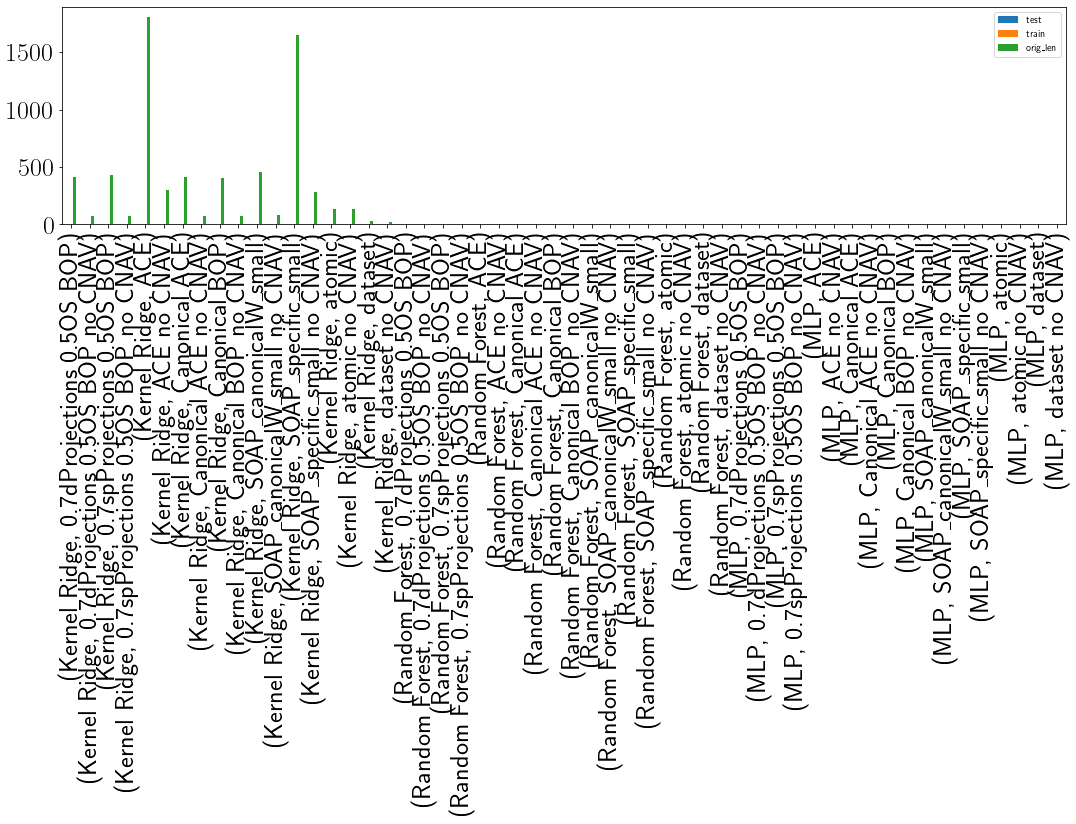

In [45]:
figwidth, figheight = plt.rcParams['figure.figsize']
OptimizedScoresDF.plot.bar(figsize=[3*figwidth, figheight])

In [46]:
unstack = OptimizedScoresDF.unstack(level=0)

In [47]:
iwanttoplot = unstack.index.difference(['SOAP', 'dataset + Projections BOP', 'Projections BOP', 'dataset + Projections sOS BOP', 'Projections OS BOP'])

In [48]:
test_scores = unstack['test'].loc[iwanttoplot].sort_values(by='Kernel Ridge', ascending=False)#.dropna(axis=0)

In [49]:
xs = {
    'ACE' : 7,
    'd BOP': 5,
    'SOAP': 6,
    'structure encoding': 4,
    'Canonical BOP': 3,
    'Canonical ACE': 2,
    'Canonical SOAP': 1,
    'atomic': 0
}

In [50]:
deltas = {
    'Kernel Ridge': 0.25,
    'Random Forest': 0,
    'MLP': -0.25
}

In [51]:
clean_label_map = {
    '.*spProjections.*BOP': 'sp BOP',
    '.*dProjections.*BOP': 'd BOP',
    'SOAP_specific_small': 'SOAP', 
    'SOAP_canonicalW_small': 'Canonical SOAP',
    'dataset' : 'structure encoding'
}
def clean_label(label):
    cleanedlabel = copy.copy(label)
    for pattern, cleanlabel in clean_label_map.items():
        cleanedlabel = re.sub(pattern, cleanlabel, cleanedlabel)
    return cleanedlabel
    

In [52]:
colors = {'Kernel Ridge': 'brown',
         'Random Forest': 'steelblue', 
          'MLP': 'mediumseagreen'}

In [53]:
def assign_x(label, debug=False):
    if debug:
        print(label)
    if label not in xs.keys():
        return None
    return xs[label]

In [54]:
test_scores_cnav = test_scores[~test_scores.index.str.contains('no CNAV')].copy()
test_scores_cnav['labels'] = test_scores_cnav.index.map(clean_label)
test_scores_nocnav = test_scores[test_scores.index.str.contains('no CNAV')].copy()
test_scores_nocnav['labels'] = test_scores_nocnav.index.map(clean_label).str.replace(' no CNAV', '')
test_scores_cnav['xs'] = test_scores_cnav.labels.map(assign_x)
test_scores_nocnav['xs'] = test_scores_nocnav.labels.map(assign_x)


In [55]:
xticks = [value for key, value in xs.items() ]

In [56]:
xlabels = [key for key, value in xs.items()]

In [57]:
{key: 2*x for key, x in xs.items()}

{'ACE': 14,
 'd BOP': 10,
 'SOAP': 12,
 'structure encoding': 8,
 'Canonical BOP': 6,
 'Canonical ACE': 4,
 'Canonical SOAP': 2,
 'atomic': 0}

In [58]:
{key: 2*d+0.25 for key, d in deltas.items()}

{'Kernel Ridge': 0.75, 'Random Forest': 0.25, 'MLP': -0.25}

In [59]:
{key: 2*d-0.25 for key, d in deltas.items()}

{'Kernel Ridge': 0.25, 'Random Forest': -0.25, 'MLP': -0.75}

In [60]:
renamed_test_scores_nocnav = test_scores_nocnav.copy()

In [61]:
renamed_test_scores_nocnav.index = renamed_test_scores_nocnav.index.str.replace(' no CNAV','')

In [62]:
ratios = {}
for model in ['Kernel Ridge', 'MLP', 'Random Forest']:
    ratios[model] = (test_scores_cnav[model]/renamed_test_scores_nocnav[model])[renamed_test_scores_nocnav.index]

In [63]:
from matplotlib.patches import FancyArrowPatch, FancyArrow
from matplotlib.lines import Line2D

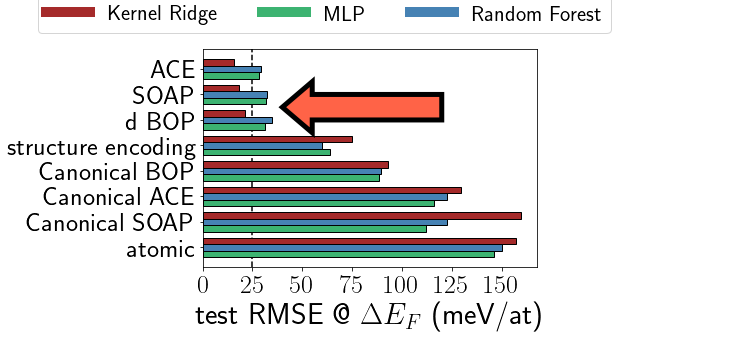

In [64]:
verts=[(-0.25,-2),(0.25,-2),(0.25,2),(-0.25,2),(-0.25,-2)]
codes = [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]
path = Path(verts, codes)
figwidth, figheight = plt.rcParams['figure.figsize']
fig, axs = plt.subplots(figsize=(figwidth,figheight), sharey=True)
plt.subplots_adjust(wspace=0.1)
m = 2
d = 0.25
w = d
handles = []
models = ['Kernel Ridge', 'MLP', 'Random Forest']
for model in models: #, 'Random Forest', 'MLP']:
    axs.barh(
        m*test_scores_cnav['xs'][ratios[model].index]+m*deltas[model],#+d, 
        test_scores_cnav[model][ratios[model].index].values*1000, m*w,
        color = colors[model],
        edgecolor='k', #colors[model],
    )
    handles.append(Line2D([],[],color=colors[model], linewidth=10))
#ax.set_xscale('log', subs=[8, 10, 15, 20,30, 40,50, 100])
axs.set_yticks([m*x for x in xticks])
axs.set_yticklabels(xlabels)
fig.legend(
    handles, models,
    ncol=len(models),
    loc=(0.05, 0.9),
    fontsize = 22
)
fancyarrow = FancyArrowPatch((120, 10.7),(40,10.7), mutation_scale=100, facecolor='tomato', linewidth=5)
fancyarrow = FancyArrow(120, 11,-80,0,width=2, head_length=15, head_width=4, length_includes_head=True, facecolor='tomato', linewidth=5)
axs.add_patch(fancyarrow)
axs.set_xticks([0,25,50,75,100,125,150])
#axs.text(60,10.75,'domain knowledge', fontsize=14)
axs.set_xlabel(r'test RMSE @ $\Delta E_F$ (meV/at)')
#fig.tight_layout()
axs.axvline(25, c='k', linestyle='--', zorder=0)
fig.savefig(os.path.join(dataset, 'graphs', f'{dataset}_CNAV_only.pdf'), bbox_inches='tight')

In [65]:
deltas

{'Kernel Ridge': 0.25, 'Random Forest': 0, 'MLP': -0.25}

In [66]:
selection = ~(test_scores_cnav.index.str.contains('SOAP_canonical') | test_scores_cnav.index.str.contains('Canonical ACE'))

In [67]:
test_scores_cnav['xs'][selection] = np.where(test_scores_cnav['xs'][selection] > 0,test_scores_cnav['xs'][selection] -2 , test_scores_cnav['xs'][selection])

/tmp/ipykernel_3156611/903731865.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  test_scores_cnav['xs'][selection] = np.where(test_scores_cnav['xs'][selection] > 0,test_scores_cnav['xs'][selection] -2 , test_scores_cnav['xs'][selection])

In [68]:
test_scores_cnav[selection]

,Kernel Ridge,MLP,Random Forest,labels,xs
atomic,0.157243,0.146035,0.150437,atomic,0.0
Canonical BOP,0.093085,0.088513,0.089620,Canonical BOP,1.0
dataset,0.074732,0.064068,0.059716,structure encoding,2.0
0.7spProjections 0.5OS BOP,0.025133,0.037158,0.038859,sp BOP,NaN
0.7dProjections 0.5OS BOP,0.021383,0.031157,0.034670,d BOP,3.0
SOAP_specific_small,0.018157,0.031860,0.032118,SOAP,4.0
ACE,0.015711,0.028454,0.029258,ACE,5.0


In [69]:
xlabels = [key for key, value in xs.items() if 'Canonical ACE' not in key and 'Canonical SOAP' not in key]

In [70]:
xlabels

['ACE', 'd BOP', 'SOAP', 'structure encoding', 'Canonical BOP', 'atomic']

In [71]:
selection

array([False,  True, False,  True,  True,  True,  True,  True,  True])

In [72]:
xs = {key: value-2 if value > 2 else value for key, value in xs.items() if 'Canonical ACE' not in key and 'Canonical SOAP' not in key}

In [73]:
xs

{'ACE': 5,
 'd BOP': 3,
 'SOAP': 4,
 'structure encoding': 2,
 'Canonical BOP': 1,
 'atomic': 0}

In [74]:
xticks = [value for key, value in xs.items()]

In [75]:
xticks

[5, 3, 4, 2, 1, 0]

In [76]:
xlabels

['ACE', 'd BOP', 'SOAP', 'structure encoding', 'Canonical BOP', 'atomic']

In [77]:
deltas

{'Kernel Ridge': 0.25, 'Random Forest': 0, 'MLP': -0.25}

In [78]:
xlabels

['ACE', 'd BOP', 'SOAP', 'structure encoding', 'Canonical BOP', 'atomic']

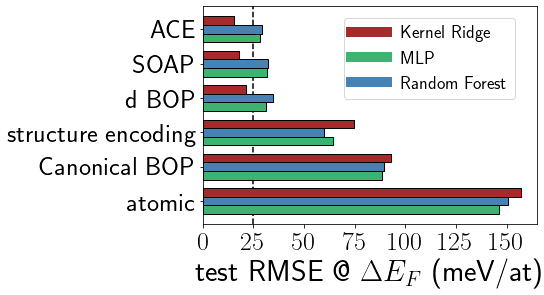

In [87]:
figwidth, figheight = plt.rcParams['figure.figsize']
fig, axs = plt.subplots(figsize=(figwidth,figheight), sharey=True)
plt.subplots_adjust(wspace=0.1)
m = 2
d = 0.25
w = d
handles = []
models = ['Kernel Ridge', 'MLP', 'Random Forest']
for model in models: #, 'Random Forest', 'MLP']:
    axs.barh(
        m*test_scores_cnav['xs'][selection]+m*deltas[model],#+d, 
        test_scores_cnav[model][selection].values*1000, m*w,
        color = colors[model],
        edgecolor='k', #colors[model],
    )
    handles.append(Line2D([],[],color=colors[model], linewidth=10))
#ax.set_xscale('log', subs=[8, 10, 15, 20,30, 40,50, 100])
axs.set_yticks([m*x for x in xticks])
axs.set_yticklabels(xlabels)
fig.legend(
    handles, models,
    ncol=1, #len(models),
    loc='center', #(0.75, 0.75),
    bbox_to_anchor=(0.65, 0.7),
    fontsize = 18
)
axs.set_xticks([0,25,50,75,100,125,150])
#axs.text(60,10.75,'domain knowledge', fontsize=14)
axs.set_xlabel(r'test RMSE @ $\Delta E_F$ (meV/at)')
#fig.tight_layout()
axs.axvline(25, c='k', linestyle='--', zorder=0)
fig.savefig(os.path.join(dataset, 'graphs', f'{dataset}_CNAV_only_nocanonicals.pdf'), bbox_inches='tight')

In [65]:
ratios['Kernel Ridge'].drop('atomic')

Canonical ACE                 0.993242
SOAP_canonicalW_small         1.239587
Canonical BOP                 0.824405
dataset                       1.046754
0.7dProjections 0.5OS BOP     0.573344
0.7spProjections 0.5OS BOP    0.765025
SOAP_specific_small           0.819915
ACE                           0.850202
Name: Kernel Ridge, dtype: float64

In [73]:
xlabels[:-1]

['ACE',
 'd BOP',
 'SOAP',
 'structure encoding',
 'Canonical BOP',
 'Canonical ACE',
 'Canonical SOAP']

In [74]:
xticks[:-1]

[7, 5, 6, 4, 3, 2, 1]

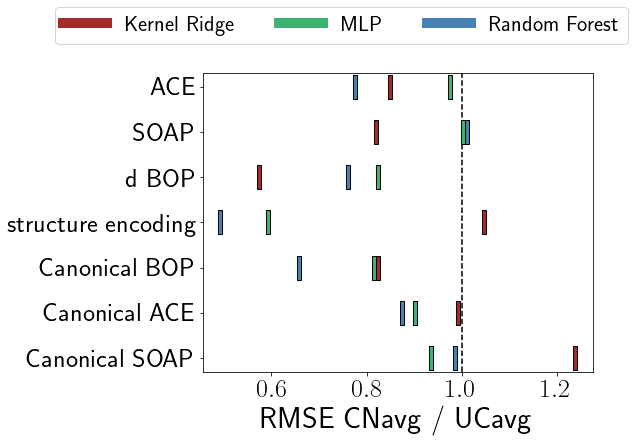

In [85]:
#verts=[(-0.25,-2),(0.25,-2),(0.25,2),(-0.25,2),(-0.25,-2)]
#codes = [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]
path = Path(verts, codes)
figwidth, figheight = plt.rcParams['figure.figsize']
fig, axs = plt.subplots(1,1, figsize=(figwidth,1.1*figheight), sharey=True)
plt.subplots_adjust(wspace=0.1)
m = 2
d = 0.25
w = d
handles = []
for model in ['Kernel Ridge', 'MLP', 'Random Forest']: #, 'Random Forest', 'MLP']:
    axs.scatter(
        ratios[model].drop('atomic'),#test_scores_cnav[model]/renamed_test_scores_nocnav[model], 
        m*test_scores_cnav['xs'][ratios[model].drop('atomic').index], 
        color = colors[model],
        marker=path,
        s=600,
        edgecolor='k', #colors[model],
    )
    handles.append(Line2D([],[],color=colors[model], linewidth=10))
axs.set_xlabel(r'RMSE CNavg / UCavg')
axs.set_yticks([m*x for x in xticks[:-1]])
axs.set_yticklabels(xlabels[:-1])
#for model in ['Kernel Ridge', 'MLP', 'Random Forest']: #, 'Random Forest', 'MLP']:
#    axs[1].barh(
#        m*test_scores_cnav['xs'][ratios[model].index]+m*deltas[model], #+d, 
#        test_scores_cnav[model][ratios[model].index].values*1000, m*w,
#        color = colors[model],
#        edgecolor='k', #colors[model],
#    )
#ax.set_xscale('log', subs=[8, 10, 15, 20,30, 40,50, 100])
#axs[1].set_xlabel(r'RMSE @$\Delta E_F$ (meV/at)')
#axs[1].set_yticks([m*x for x in xticks])
#axs[1].set_yticklabels(xlabels)
fig.legend(
    handles,
#    [Patch(facecolor='brown'),
#     Patch(facecolor='darkblue'),
#     Patch(facecolor='mediumseagreen')
#     Patch(facecolor=(1,1,1,0.5), hatch='/', ec='black')
#    ],
    models, #+['no CNAV'],
    ncol=len(models),
    loc='center',
    bbox_to_anchor=(0.4, 1),
    fontsize = 22

)
#fancyarrow = FancyArrowPatch((100, 10.75),(30,10.75), mutation_scale=100, facecolor='tomato', linewidth=5)
#fancyarrow = FancyArrow(120, 11,-80,0,width=2, head_length=15, head_width=4, length_includes_head=True, facecolor='tomato', linewidth=5)
#axs[-1].add_patch(fancyarrow)
#axs[-1].add_patch(fancyarrow)
#axs[-1].text(60,10.75,'domain knowledge', fontsize=14)
#axs[-1].set_xticks([0,25,50,75,100,125,150])
#fig.tight_layout()
axs.axvline(1, c='k', linestyle='--', zorder=0)
#axs[1].axvline(25, c='k', linestyle='--', zorder=0)
fig.savefig(os.path.join(dataset, 'graphs', f'{dataset}_CNAV_vs_noCNAV.pdf'), bbox_inches='tight')

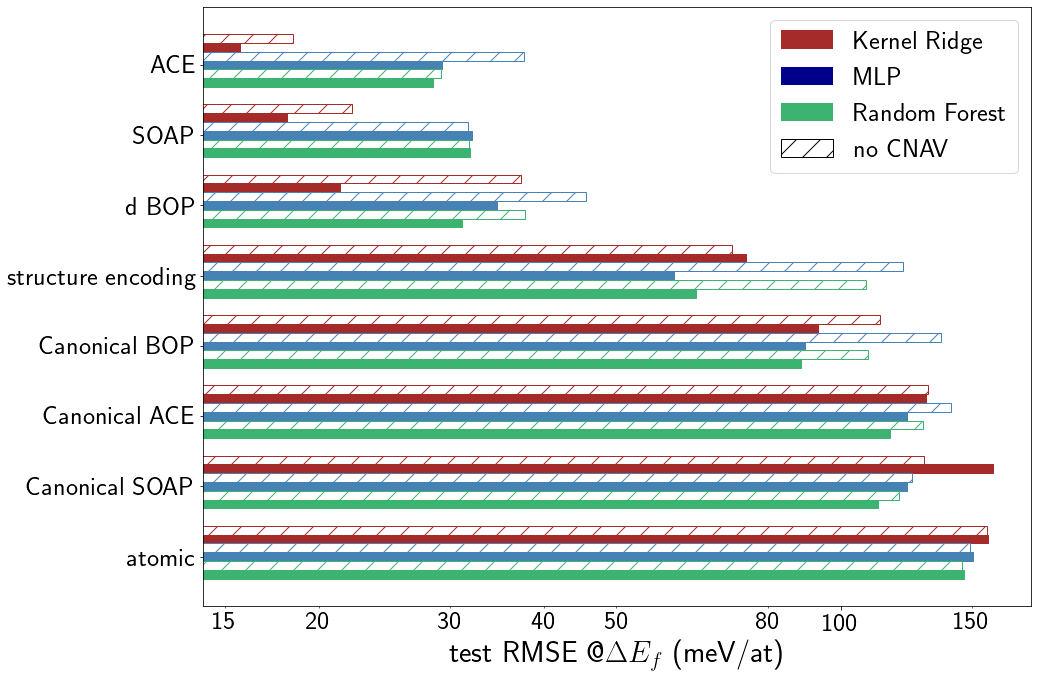

In [58]:
fig, ax = plt.subplots(figsize=(15,10))
m = 2
d = 0.25
w = d
for model in ['Kernel Ridge', 'Random Forest', 'MLP']:
    ax.barh(
        m*test_scores_nocnav['xs'].values+m*deltas[model]+d,
        test_scores_nocnav[model].values*1000, w,
        color = colors[model],
        facecolor=(1,1,1,1),
        hatch = '/',
#        linewidth = 5
    )
    ax.barh(
        m*test_scores_nocnav['xs'].values+m*deltas[model]+d,
        test_scores_nocnav[model].values*1000, w,
        color = colors[model],
        facecolor=(1,1,1,1),
        hatch = '/',
        edgecolor=colors[model],
#        linewidth=5
    )
    ax.barh(
        m*test_scores_cnav['xs'].values+m*deltas[model],
        test_scores_cnav[model].values*1000, w,
        color = colors[model],
        edgecolor=colors[model],
#        linewidth=5,
#        zorder = 1
    )
ax.set_xscale('log', subs=[8, 10, 15, 20,30, 40,50, 100])
ax.tick_params(axis='x', which='minor')
ax.xaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.tick_params(axis='x', which='major')
ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.set_xlabel(r'test RMSE @$\Delta E_f$ (meV/at)')
ax.set_yticks([m*x for x in xticks])
ax.set_yticklabels(xlabels)
plt.legend(
    [Patch(facecolor='brown'),
     Patch(facecolor='darkblue'),
     Patch(facecolor='mediumseagreen'), 
     Patch(facecolor=(1,1,1,0.5), hatch='/', ec='black')
    ],
    models+['no CNAV'],
    ncol=1,
)
fig.tight_layout()
fig.savefig(os.path.join(dataset, 'graphs', f'{dataset}_OptimalRegresorComparison.pdf'))